# Boolean GRNs Control: FVS Upper Bounds + Stable Motif Control

This notebook combines two complementary control perspectives for an inferred Boolean GRN:

1. **FVS structural control bound** (Fiedler et al., 2013): gives a structural upper bound for control and observation sets.
2. **Stable motif attractor control** (Rozum et al., 2015): gives attractor-specific interventions that are typically small.

Important caveat used throughout:

- The FVS set is an **upper bound**, not necessarily the minimal attractor-specific driver set.
- Stable motif control sets are attractor-specific, but are not guaranteed globally minimal.
- The **control kernel** (true minimal driver set for one target attractor) is generally a subset of both candidate sets and is usually unknown a priori.

## 1) Imports and package setup

This cell imports analysis libraries and loads `pystablemotifs`. The stderr redirection only suppresses optional executable warnings (Graphviz checks) and does not affect computations.

In [29]:
import io
import contextlib
from itertools import combinations, product

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

import biobalm as balm
from biobalm import control as balm_control
from biodivine_aeon import BooleanNetwork

# PyStableMotifs prints optional executable checks to stderr at import time.
with contextlib.redirect_stderr(io.StringIO()):
    import pystablemotifs as sm

## 2) Reusable analysis functions

This cell defines reusable utilities for: (i) converting rules into a directed regulatory graph, (ii) computing FVS-based structural bounds, (iii) extracting attractor seeds, and (iv) finding control sets constrained to a structural candidate set.

In [30]:
def build_bn_and_graph(rule_text):
    """Parse a bnet-style rule string into an AEON BooleanNetwork and a NetworkX DiGraph."""
    bn = BooleanNetwork.from_bnet(rule_text)
    graph = nx.DiGraph()

    for name in bn.variable_names():
        graph.add_node(name)

    for reg in bn.regulations():
        src = bn.get_variable_name(reg["source"])
        tgt = bn.get_variable_name(reg["target"])
        graph.add_edge(src, tgt, sign=reg.get("sign"), essential=reg.get("essential", None))

    return bn, graph


def minimum_fvs_sets_exact(graph, max_nodes_exact=18):
    """
    Enumerate all minimum-cardinality FVS solutions for small/medium directed graphs.
    Returns a list of sets (possibly empty if the graph is already acyclic).
    """
    n = graph.number_of_nodes()
    nodes = list(graph.nodes())

    if nx.is_directed_acyclic_graph(graph):
        return [set()]

    if n > max_nodes_exact:
        # Conservative fallback for large networks: remove high-feedback nodes greedily.
        g_work = graph.copy()
        picked = set()
        while not nx.is_directed_acyclic_graph(g_work):
            score = {
                node: g_work.in_degree(node) * g_work.out_degree(node)
                for node in g_work.nodes()
            }
            to_remove = max(score, key=score.get)
            picked.add(to_remove)
            g_work.remove_node(to_remove)
        return [picked]

    for k in range(1, n + 1):
        solutions = []
        for subset in combinations(nodes, k):
            reduced = graph.copy()
            reduced.remove_nodes_from(subset)
            if nx.is_directed_acyclic_graph(reduced):
                solutions.append(set(subset))
        if solutions:
            return solutions

    return [set(nodes)]


def structural_control_bounds(rule_text):
    """
    Compute structural FVS-based upper bounds for control/observation.

    Driver upper bound: source nodes U one minimum FVS of the forward graph.
    Sensor upper bound: sink nodes U one minimum FVS of the reversed graph.
    """
    bn, graph = build_bn_and_graph(rule_text)

    source_nodes = sorted([n for n in graph.nodes if graph.in_degree(n) == 0])
    sink_nodes = sorted([n for n in graph.nodes if graph.out_degree(n) == 0])

    # AEON provides one minimum FVS directly on the forward graph.
    fvs_forward_aeon = sorted(bn.get_variable_name(v) for v in bn.feedback_vertex_set())

    # Exact enumeration is used to expose alternative minimum FVS solutions.
    fvs_forward_all = [sorted(s) for s in minimum_fvs_sets_exact(graph)]
    fvs_reverse_all = [sorted(s) for s in minimum_fvs_sets_exact(graph.reverse(copy=True))]

    fvs_forward_choice = fvs_forward_all[0] if fvs_forward_all else []
    fvs_reverse_choice = fvs_reverse_all[0] if fvs_reverse_all else []

    driver_upper_bound = sorted(set(source_nodes) | set(fvs_forward_choice))
    sensor_upper_bound = sorted(set(sink_nodes) | set(fvs_reverse_choice))

    metrics = {
        "n_nodes": graph.number_of_nodes(),
        "n_edges": graph.number_of_edges(),
        "n_sources": len(source_nodes),
        "n_sinks": len(sink_nodes),
        "min_fvs_size_forward": len(fvs_forward_choice),
        "min_fvs_size_reverse": len(fvs_reverse_choice),
        "driver_upper_bound_size": len(driver_upper_bound),
        "sensor_upper_bound_size": len(sensor_upper_bound),
    }

    return {
        "bn": bn,
        "graph": graph,
        "source_nodes": source_nodes,
        "sink_nodes": sink_nodes,
        "fvs_forward_aeon": fvs_forward_aeon,
        "fvs_forward_all": fvs_forward_all,
        "fvs_reverse_all": fvs_reverse_all,
        "driver_upper_bound": driver_upper_bound,
        "sensor_upper_bound": sensor_upper_bound,
        "metrics": metrics,
    }


def attractor_seeds_dataframe(rule_text):
    """Build the succession diagram and return attractor seeds as a dataframe."""
    sd = balm.SuccessionDiagram.from_rules(rule_text)
    sd.build()
    seeds = sd.expanded_attractor_seeds()
    flat = {k: v[0] for k, v in seeds.items()}
    df = pd.DataFrame.from_dict(flat, orient="index").sort_index()
    df.index.name = "attractor_id"
    return sd, seeds, df


def normalize_balm_interventions(interventions):
    """
    Convert BioBaLM interventions into unique partial-state controls.
    Each returned dict is one control assignment candidate.
    """
    controls = []
    seen = set()

    for intervention in interventions:
        for control_path in intervention.control:
            merged = {}
            consistent = True
            for override in control_path:
                for node, value in override.items():
                    if node in merged and merged[node] != value:
                        consistent = False
                        break
                    merged[node] = value
                if not consistent:
                    break
            if consistent:
                merged = dict(sorted(merged.items()))
                key = tuple(merged.items())
                if key not in seen:
                    seen.add(key)
                    controls.append(merged)

    controls.sort(key=lambda d: (len(d), sorted(d.items())))
    return controls


def constrained_ldoi_controls(primes, target, allowed_nodes, max_size=4):
    """
    Search minimal controls restricted to `allowed_nodes` using LDOI inclusion.
    Returns controls of smallest size that imply the entire target partial state.
    """
    allowed = sorted(set(allowed_nodes))
    max_size = min(max_size, len(allowed))

    for k in range(1, max_size + 1):
        found = []
        for nodes in combinations(allowed, k):
            for values in product([0, 1], repeat=k):
                candidate = dict(zip(nodes, values))
                implied, contradicted = sm.drivers.logical_domain_of_influence(candidate, primes)

                if any(node in contradicted and contradicted[node] == val for node, val in target.items()):
                    continue

                if all(implied.get(node) == val for node, val in target.items()):
                    found.append(dict(sorted(candidate.items())))

        if found:
            # Deduplicate while preserving order.
            unique = []
            seen = set()
            for c in found:
                key = tuple(c.items())
                if key not in seen:
                    seen.add(key)
                    unique.append(c)
            return unique

    return []

## 3) Select the inferred GRN

This cell keeps your original inferred rule candidates and activates one (`next_r` by default). You can switch to another key in `RULES` to reuse the exact same pipeline.

In [31]:
# Inferred GRN rules from the original notebook.
RULES = {
    "rule": """COUP, !FGF8\nEMX2, !SP8\nFGF8, SP8\nPAX6, SP8\nSP8, FGF8""",
    "rule_2": "COUP, EMX2\nEMX2, !FGF8\nFGF8, SP8\nPAX6, !EMX2\nSP8, FGF8",
    "next_r": "COUP,   !SP8&!PAX6&COUP | !FGF8 | EMX2\nEMX2,   !SP8 | !FGF8 | EMX2\nFGF8,   PAX6 | !COUP\nPAX6,   !EMX2\nSP8,    !EMX2\n",
}

active_rule_name = "next_r"
rule_text = RULES[active_rule_name]

print(f"Using inferred GRN: {active_rule_name}")
print(rule_text)

Using inferred GRN: next_r
COUP,   !SP8&!PAX6&COUP | !FGF8 | EMX2
EMX2,   !SP8 | !FGF8 | EMX2
FGF8,   PAX6 | !COUP
PAX6,   !EMX2
SP8,    !EMX2



## 4) Structural control bounds from FVS

This cell computes source/sink nodes, minimum FVS solutions, and two structural upper bounds:

- `driver_upper_bound = sources ∪ forward-FVS`
- `sensor_upper_bound = sinks ∪ reverse-FVS`

These are structural candidate sets, not guaranteed minimal control kernels.

In [32]:
struct = structural_control_bounds(rule_text)
graph = struct["graph"]

metrics_df = pd.DataFrame(struct["metrics"], index=[0]).T.rename(columns={0: "value"})
metrics_df.index.name = "metric"

fvs_rows = [
    {
        "solution_type": "forward_min_fvs",
        "nodes": ", ".join(nodes),
        "size": len(nodes),
    }
    for nodes in struct["fvs_forward_all"]
]
fvs_rows += [
    {
        "solution_type": "reverse_min_fvs",
        "nodes": ", ".join(nodes),
        "size": len(nodes),
    }
    for nodes in struct["fvs_reverse_all"]
]
fvs_df = pd.DataFrame(fvs_rows)

print("Source nodes:", struct["source_nodes"])
print("Sink nodes:", struct["sink_nodes"])
print("Driver upper bound:", struct["driver_upper_bound"])
print("Sensor upper bound:", struct["sensor_upper_bound"])
print("AEON one minimum FVS (forward):", struct["fvs_forward_aeon"])

metrics_df

Source nodes: []
Sink nodes: []
Driver upper bound: ['COUP', 'EMX2']
Sensor upper bound: ['COUP', 'EMX2']
AEON one minimum FVS (forward): ['COUP', 'EMX2']


,value
metric,
n_nodes,5
n_edges,12
n_sources,0
n_sinks,0
min_fvs_size_forward,2
min_fvs_size_reverse,2
driver_upper_bound_size,2
sensor_upper_bound_size,2


## 5) Visualize the GRN and structural metrics

This cell shows the directed network with color-coded structural roles and summarizes bound sizes, helping interpret which nodes are structurally privileged for control or observation.

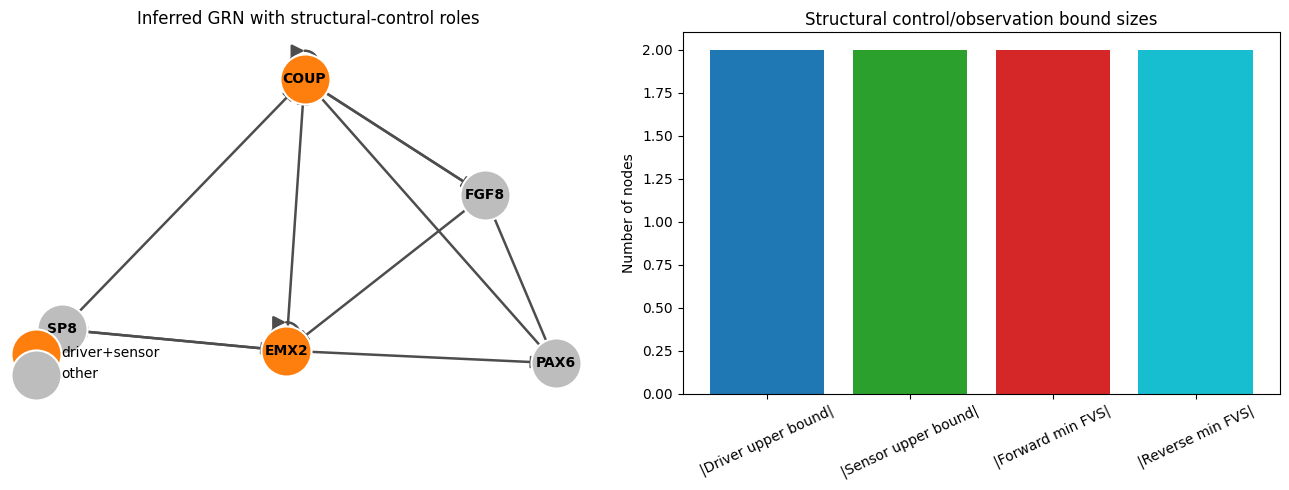

In [33]:
node_role = {}
for n in graph.nodes:
    in_driver = n in struct["driver_upper_bound"]
    in_sensor = n in struct["sensor_upper_bound"]
    in_fvs = any(n in s for s in struct["fvs_forward_all"])

    if in_driver and in_sensor:
        node_role[n] = "driver+sensor"
    elif in_driver:
        node_role[n] = "driver-bound"
    elif in_sensor:
        node_role[n] = "sensor-bound"
    elif in_fvs:
        node_role[n] = "fvs-only"
    else:
        node_role[n] = "other"

role_color = {
    "driver+sensor": "#ff7f0e",
    "driver-bound": "#1f77b4",
    "sensor-bound": "#2ca02c",
    "fvs-only": "#9467bd",
    "other": "#bdbdbd",
}

pos = nx.spring_layout(graph, seed=7)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nx.draw_networkx_edges(graph, pos, ax=axes[0], arrowstyle="-|>", arrowsize=18, width=1.8, edge_color="#4d4d4d")
for role, color in role_color.items():
    nodes = [n for n, r in node_role.items() if r == role]
    if nodes:
        nx.draw_networkx_nodes(
            graph,
            pos,
            nodelist=nodes,
            ax=axes[0],
            node_color=color,
            node_size=1300,
            edgecolors="white",
            linewidths=1.5,
            label=role,
        )
nx.draw_networkx_labels(graph, pos, ax=axes[0], font_size=10, font_weight="bold")
axes[0].set_title("Inferred GRN with structural-control roles")
axes[0].axis("off")
axes[0].legend(loc="lower left", frameon=False)

bound_sizes = pd.Series(
    {
        "|Driver upper bound|": len(struct["driver_upper_bound"]),
        "|Sensor upper bound|": len(struct["sensor_upper_bound"]),
        "|Forward min FVS|": len(struct["fvs_forward_all"][0]) if struct["fvs_forward_all"] else 0,
        "|Reverse min FVS|": len(struct["fvs_reverse_all"][0]) if struct["fvs_reverse_all"] else 0,
    }
)

axes[1].bar(bound_sizes.index, bound_sizes.values, color=["#1f77b4", "#2ca02c", "#d62728", "#17becf"])
axes[1].set_ylabel("Number of nodes")
axes[1].set_title("Structural control/observation bound sizes")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 6) Attractor seeds from the inferred GRN

This cell builds the succession diagram (BioBaLM) and lists attractor seeds. We will choose one attractor as the desired target phenotype.

In [34]:
sd, seeds, attractor_df = attractor_seeds_dataframe(rule_text)

print(f"Number of attractor seeds: {len(attractor_df)}")
attractor_df

Number of attractor seeds: 2


,PAX6,FGF8,COUP,EMX2,SP8
attractor_id,,,,,
1,0,0,1,1,0
2,1,1,0,0,1


## 7) Choose a desired attractor (target)

Pick one attractor ID from the table. The target is represented as a partial state dictionary and used by both control methods below.

In [35]:
# Change this ID to test control toward a different attractor seed.
target_attractor_id = int(attractor_df.index[0])
target_state = {k: int(v) for k, v in attractor_df.loc[target_attractor_id].to_dict().items()}

print("Selected attractor ID:", target_attractor_id)
print("Target partial state:", target_state)

Selected attractor ID: 1
Target partial state: {'PAX6': 0, 'FGF8': 0, 'COUP': 1, 'EMX2': 1, 'SP8': 0}


## 8) Attractor-specific control (stable motifs)

This cell computes two attractor-oriented control outputs:

1. **Succession-diagram interventions** with BioBaLM (`succession_control`).
2. **Small driver sets** with PyStableMotifs (`minimal_drivers`).

Both are target-specific and often tighter than structural upper bounds, but neither is guaranteed to equal the true control kernel.

In [37]:
balm_interventions = balm_control.succession_control(sd, target_state, strategy="internal")
balm_controls = normalize_balm_interventions(balm_interventions)

primes = sm.format.bnet_text2primes(rule_text)
psm_minimal = [dict(sorted(c.items())) for c in sm.drivers.minimal_drivers(target_state, primes)]
psm_internal = [dict(sorted(c.items())) for c in sm.drivers.internal_drivers(target_state, primes)]

fvs_restricted_controls = constrained_ldoi_controls(
    primes=primes,
    target=target_state,
    allowed_nodes=struct["driver_upper_bound"],
    max_size=min(4, max(1, len(struct["driver_upper_bound"]))),
)


def controls_to_table(method_name, controls):
    if not controls:
        return pd.DataFrame([
            {"method": method_name, "control": "(none found)", "size": None}
        ])
    return pd.DataFrame(
        [
            {
                "method": method_name,
                "control": ", ".join(f"{k}={v}" for k, v in c.items()),
                "size": len(c),
            }
            for c in controls
        ]
    )


control_df = pd.concat(
    [
        controls_to_table("BioBaLM succession_control", balm_controls),
        controls_to_table("PyStableMotifs minimal_drivers", psm_minimal),
        controls_to_table("PyStableMotifs internal_drivers", psm_internal),
        controls_to_table("FVS-restricted (LDOI search)", fvs_restricted_controls),
    ],
    ignore_index=True,
)

control_df

,method,control,size
0,BioBaLM succession_control,EMX2=1,1
1,PyStableMotifs minimal_drivers,EMX2=1,1
2,PyStableMotifs minimal_drivers,FGF8=0,1
3,PyStableMotifs minimal_drivers,SP8=0,1
4,PyStableMotifs internal_drivers,EMX2=1,1
5,PyStableMotifs internal_drivers,FGF8=0,1
6,PyStableMotifs internal_drivers,SP8=0,1
7,PyStableMotifs internal_drivers,"EMX2=1, FGF8=0",2
8,PyStableMotifs internal_drivers,"EMX2=1, PAX6=0",2
9,PyStableMotifs internal_drivers,"EMX2=1, SP8=0",2


## 9) Compare candidate sets and interpret kernels vs bounds

This final step compares set sizes and overlaps.

Interpretation reminder:

- **FVS bounds** are structural upper bounds for feasible control/observation strategies.
- **Stable motif controls** are attractor-specific candidates, usually smaller.
- The **control kernel** (true minimum for this target attractor) may be a strict subset of both and is not guaranteed by either method alone.

Best BioBaLM control: {'EMX2': 1}
Best PyStableMotifs control: {'EMX2': 1}
Best FVS-restricted control: {'EMX2': 1}


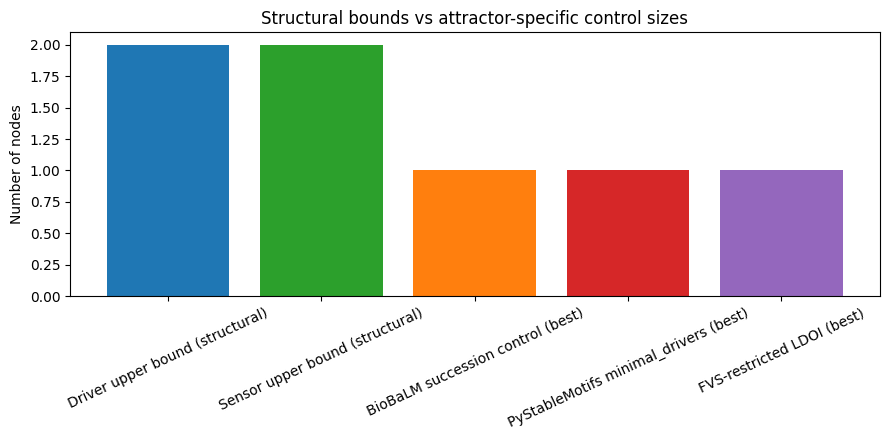

(                                     set  size
 0        Driver upper bound (structural)     2
 1        Sensor upper bound (structural)     2
 2      BioBaLM succession control (best)     1
 3  PyStableMotifs minimal_drivers (best)     1
 4             FVS-restricted LDOI (best)     1,
                      candidate   nodes  subset_of_driver_upper_bound
 0         Best BioBaLM control  [EMX2]                          True
 1  Best PyStableMotifs control  [EMX2]                          True
 2  Best FVS-restricted control  [EMX2]                          True)

In [38]:
def min_control_size(controls):
    return min((len(c) for c in controls), default=None)

size_summary = pd.DataFrame(
    {
        "set": [
            "Driver upper bound (structural)",
            "Sensor upper bound (structural)",
            "BioBaLM succession control (best)",
            "PyStableMotifs minimal_drivers (best)",
            "FVS-restricted LDOI (best)",
        ],
        "size": [
            len(struct["driver_upper_bound"]),
            len(struct["sensor_upper_bound"]),
            min_control_size(balm_controls),
            min_control_size(psm_minimal),
            min_control_size(fvs_restricted_controls),
        ],
    }
)

best_balm = min(balm_controls, key=len) if balm_controls else {}
best_psm = min(psm_minimal, key=len) if psm_minimal else {}
best_fvs_restricted = min(fvs_restricted_controls, key=len) if fvs_restricted_controls else {}

overlap_df = pd.DataFrame(
    [
        {
            "candidate": "Best BioBaLM control",
            "nodes": sorted(best_balm.keys()),
            "subset_of_driver_upper_bound": set(best_balm).issubset(struct["driver_upper_bound"]),
        },
        {
            "candidate": "Best PyStableMotifs control",
            "nodes": sorted(best_psm.keys()),
            "subset_of_driver_upper_bound": set(best_psm).issubset(struct["driver_upper_bound"]),
        },
        {
            "candidate": "Best FVS-restricted control",
            "nodes": sorted(best_fvs_restricted.keys()),
            "subset_of_driver_upper_bound": set(best_fvs_restricted).issubset(struct["driver_upper_bound"]),
        },
    ]
)

print("Best BioBaLM control:", best_balm)
print("Best PyStableMotifs control:", best_psm)
print("Best FVS-restricted control:", best_fvs_restricted)

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = size_summary.dropna().copy()
ax.bar(plot_df["set"], plot_df["size"], color=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"])
ax.set_ylabel("Number of nodes")
ax.set_title("Structural bounds vs attractor-specific control sizes")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

size_summary, overlap_df